In [12]:
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install seaborn
!pip install matplotlib

In [13]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

In [14]:
data = pd.read_csv("university_student_stress_dataset.csv")

## Exploratory Data Analysis

First, we want to look at the distribution of all the Stress levels

   Age  Gender  Study_Hours  Class_Attendance Tuition  Exam_Frequency  \
0   24    Male            9                71      No               7   
1   24  Female            8                43     Yes               6   
2   21  Female            4                56     Yes               3   
3   23  Female            4                46      No               8   
4   20    Male            8                46      No               5   

   Assignment_Load  Sleep_Hours Physical_Exercise  Social_Media_Use  \
0                4            6               Yes                 6   
1                8            5               Yes                 6   
2                6            5               Yes                 7   
3                6            8                No                 5   
4                1            6               Yes                 0   

   Screen_Time Family_Income_Level  Peer_Pressure  Family_Support  \
0            9                 Low              6               3

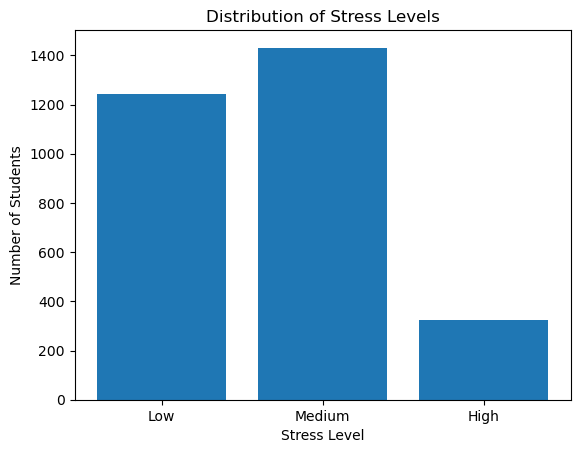

<Figure size 500x400 with 0 Axes>

In [15]:
y = data["Stress_Level"].map({"Low":0 , "Medium":1, "High":2})
val = y.value_counts()

print(data.head())
plt.bar(["Low", "Medium", "High"], (val[0], val[1], val[2]))
plt.xlabel("Stress Level")
plt.ylabel("Number of Students")
plt.title("Distribution of Stress Levels")
plt.figure(figsize=(5,4))
plt.show()

The data shows that the distribution is imbalanced, particularly students in the high stress level category have significantly less people compared to the other levels, this suggests that the model might have reduced capabilities in predicting students with high stress levels. If high stress level students show similar and characteristics however, the model still should be able to perform well

Next, we analyze the features' distribution

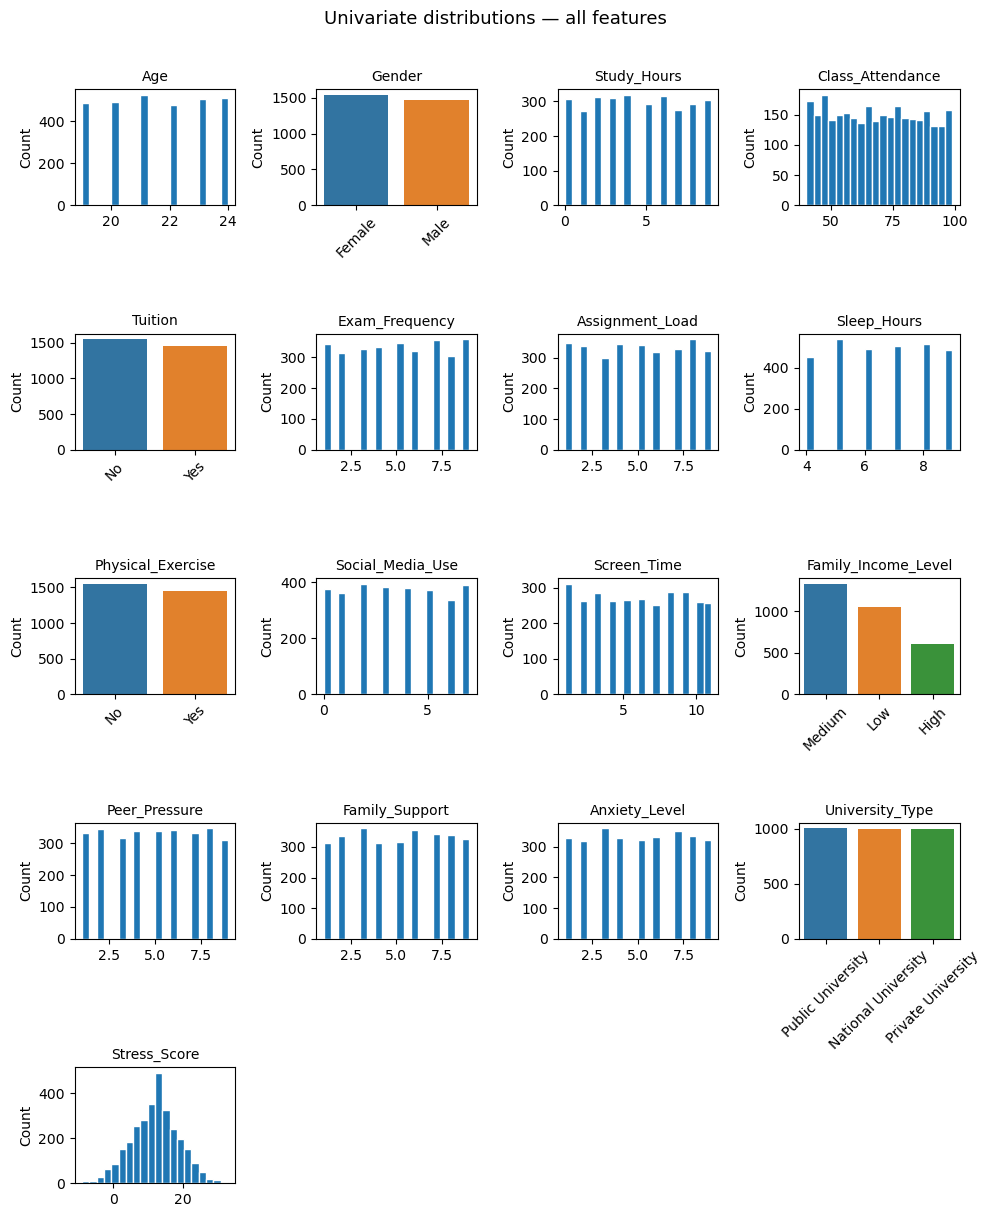

In [16]:
feature_cols = [c for c in data.columns if c != "Stress_Level"]
plot_data = data.copy()

code_map = {
    "Gender": {0: "Male", 1: "Female"},
    "Tuition": {0: "No", 1: "Yes"},
    "Family_Income_Level": {0: "Low", 1: "Medium", 2: "High"},
    "University_Type": {0: "Public University", 1: "National University", 2: "Private University"},
    "Stress_Level": {0: "Low", 1: "Medium", 2: "High"}
}

for col, mapping in code_map.items():
    if col in plot_data.columns and plot_data[col].dropna().isin(mapping.keys()).all():
        plot_data[col] = plot_data[col].map(mapping)

cat_cols = plot_data.select_dtypes(include=["object", "string"]).columns.tolist()

fig, axes = plt.subplots(5, 4, figsize=(10, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    if col in cat_cols:
        order = plot_data[col].value_counts().index
        sb.countplot(x=col, data=plot_data, order=order, ax=axes[i])
        axes[i].set_ylabel("Count")
        axes[i].tick_params(axis="x", rotation=45)
    else:
        axes[i].hist(plot_data[col].dropna(), edgecolor="white", bins=20)
        axes[i].set_ylabel("Count")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")

# Hide any unused subplot slots
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Univariate distributions — all features", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

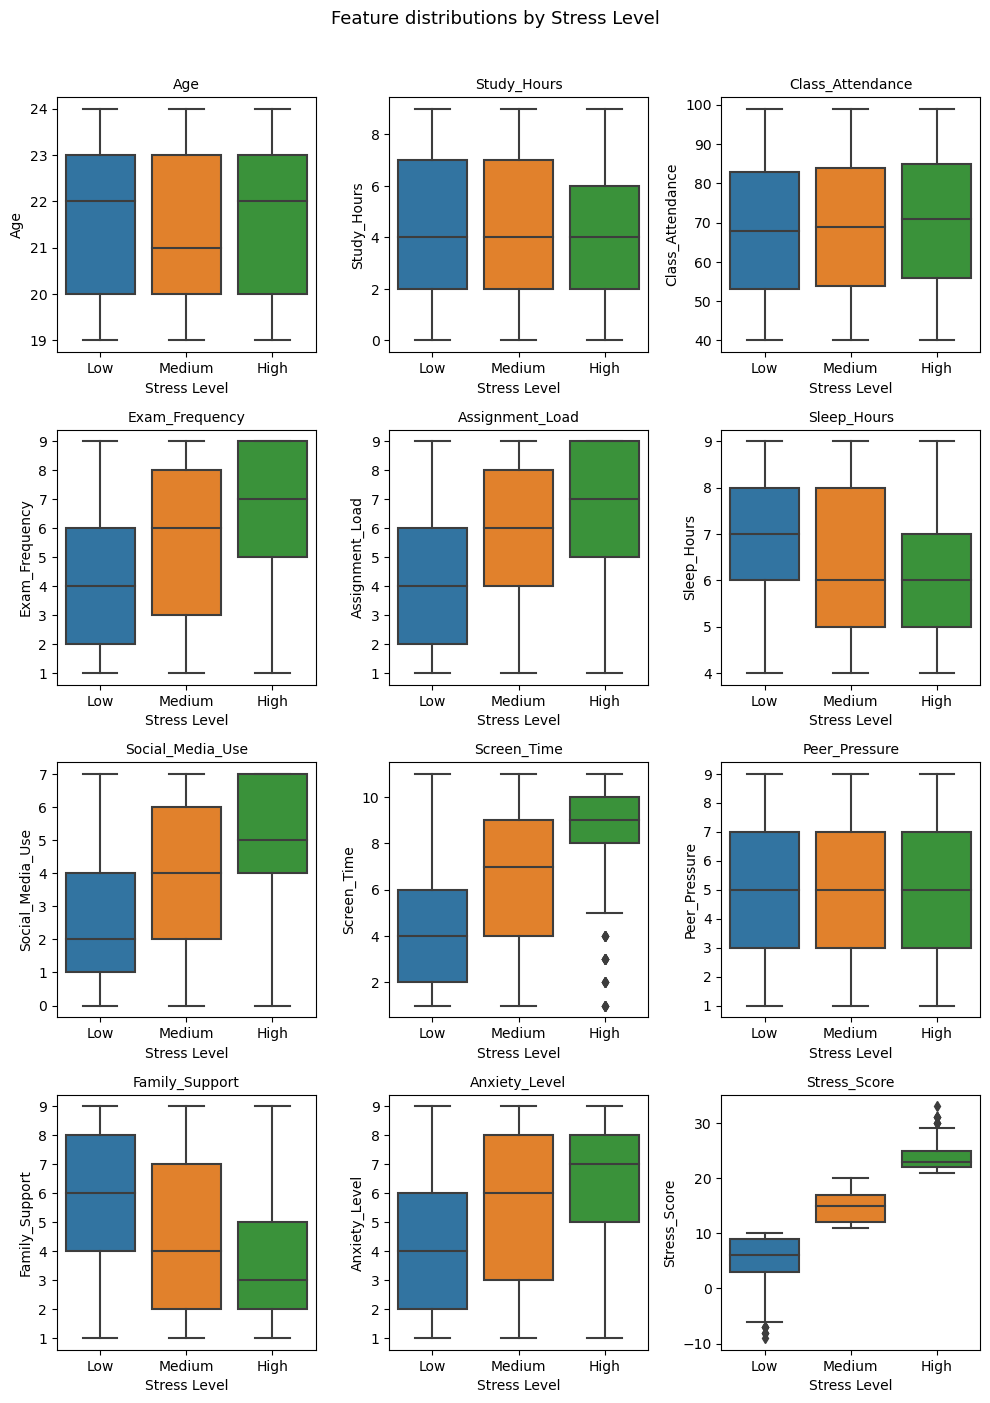

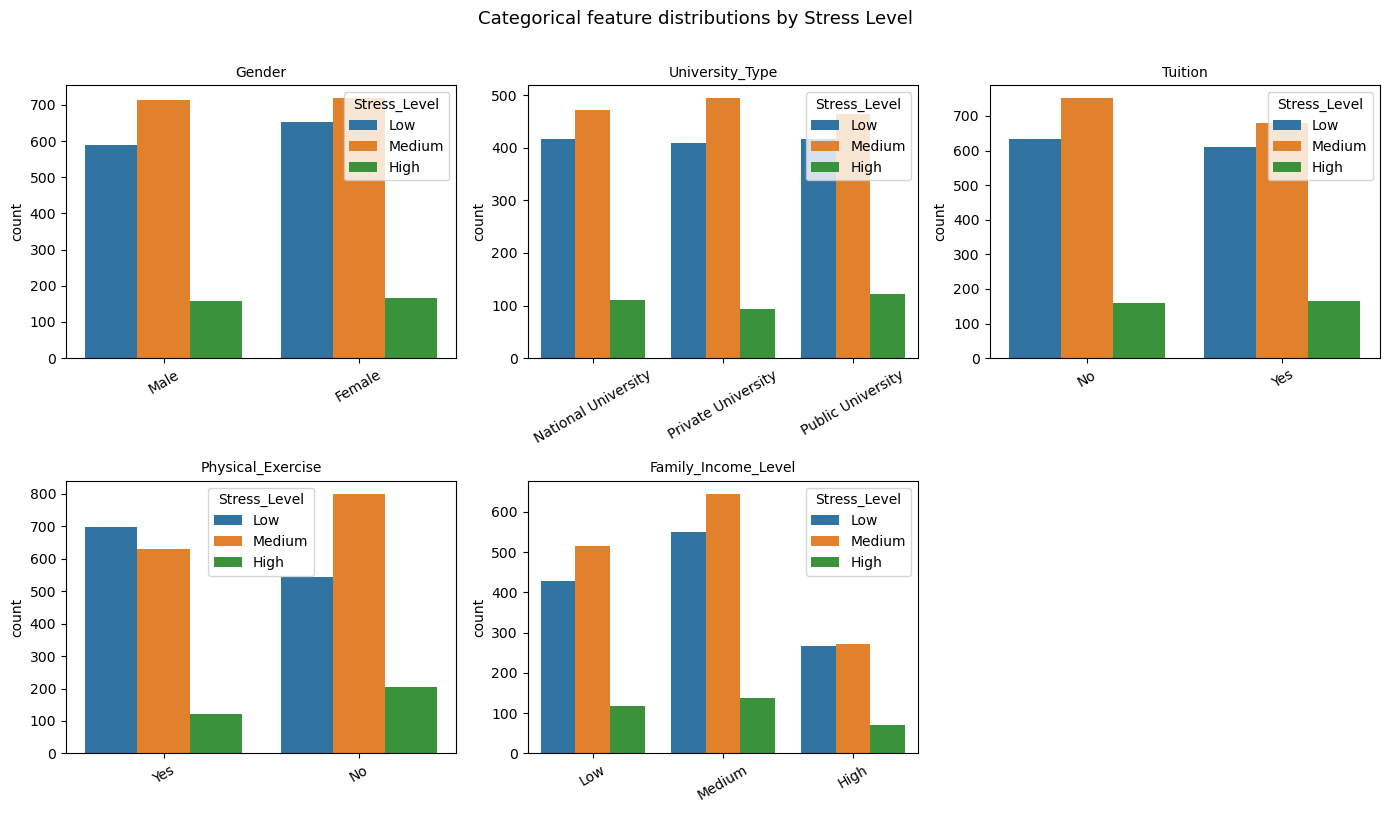

In [17]:
numeric_cols = plot_data.select_dtypes(include=["number"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "Stress_Level"]

fig, axes = plt.subplots(6, 3, figsize=(10, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sb.boxplot(data=plot_data, x="Stress_Level", y=col, ax=axes[i], order=["Low", "Medium", "High"])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("Stress Level")

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature distributions by Stress Level", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

cat_features = ["Gender", "University_Type", "Tuition", "Physical_Exercise", "Family_Income_Level"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sb.countplot(data=plot_data, x=col, hue="Stress_Level",
                 hue_order=["Low", "Medium", "High"], ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=30)

for j in range(len(cat_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Categorical feature distributions by Stress Level", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

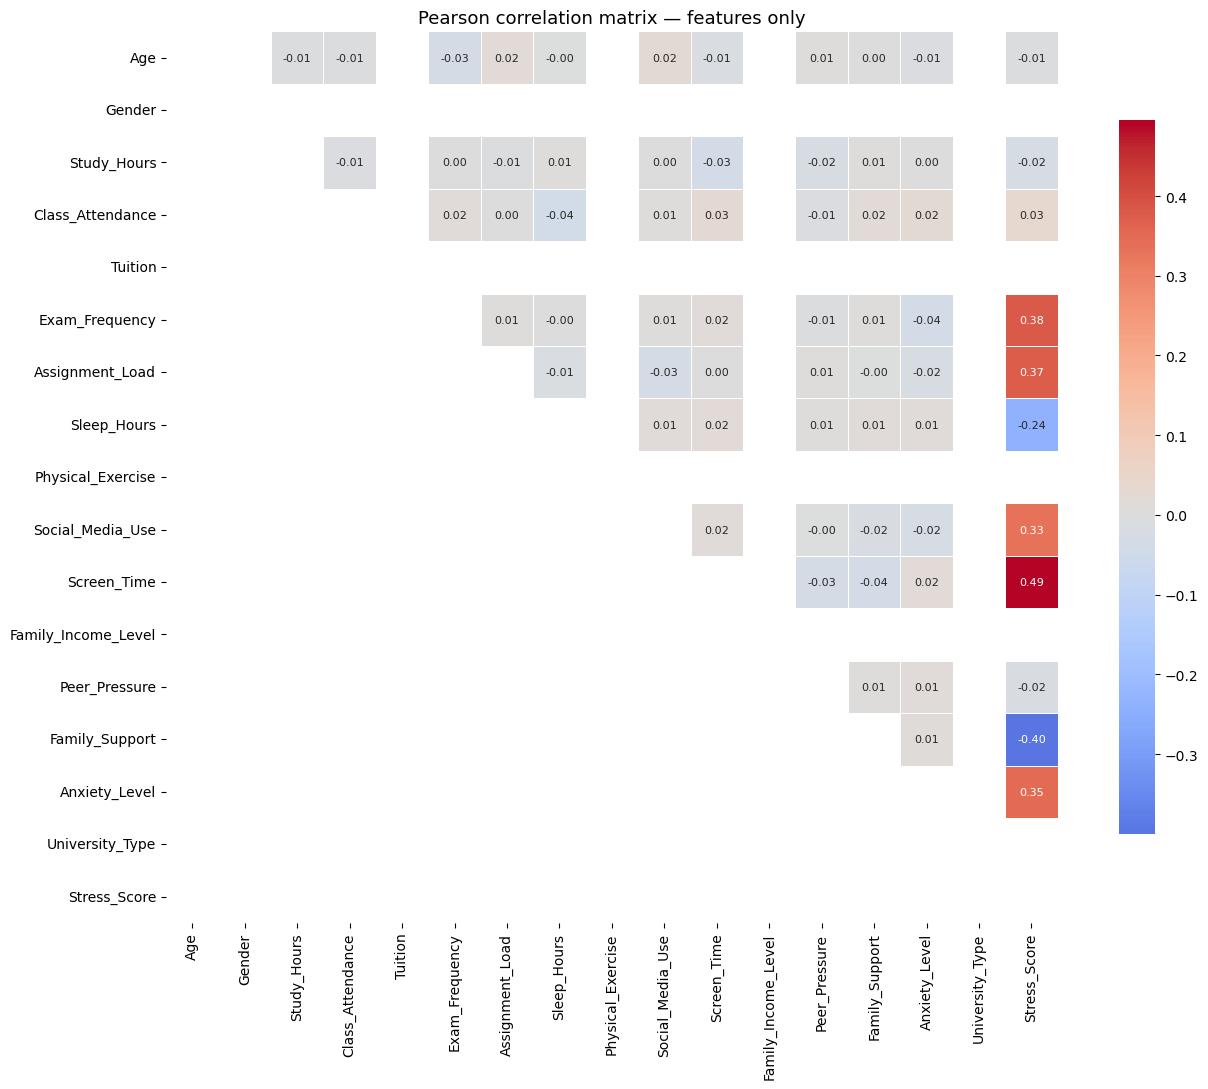

Highly correlated pairs (|r| > 0.5): none


In [18]:
# Build a numeric-only DataFrame for correlation to avoid converting non-numeric strings like 'Yes'
corr_data = data.copy()

# Drop Stress_Level from the feature correlation plot
corr_data = corr_data.drop(columns=["Stress_Level"], errors="ignore")

# Coerce any remaining convertible columns to numeric, non-convertible values become NaN
for c in corr_data.columns:
    corr_data[c] = pd.to_numeric(corr_data[c], errors='coerce')

# Compute correlation on numeric columns only
corr = corr_data.corr()

# Use upper triangle only and remove diagonal self-correlations
upper_mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
filtered_corr = corr.where(upper_mask)

fig, ax = plt.subplots(figsize=(14, 11))
sb.heatmap(filtered_corr, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.4,
            square=True, ax=ax, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 8})

ax.set_title("Pearson correlation matrix — features only", fontsize=13)
plt.tight_layout()
plt.show()

# Print pairs with |r| > 0.5 for quick review
high_corr = (filtered_corr.abs()
               .stack()
               .loc[lambda s: s > 0.5]
               .sort_values(ascending=False))
if high_corr.empty:
    print("Highly correlated pairs (|r| > 0.5): none")
else:
    print("Highly correlated pairs (|r| > 0.5):\n", high_corr.to_string())


In [23]:
df = data.copy()

df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})
df["Tuition"] = df["Tuition"].map({"No": 0, "Yes": 1})
df["Family_Income_Level"] = df["Family_Income_Level"].map({"Low" : 0, "Medium" : 1,"High" : 2})
df["University_Type"] = df["University_Type"].map({"Public University": 0, "National University": 1, "Private University": 2})
df["Stress_Level"] = df["Stress_Level"].map({"Low": 0, "Medium": 1, "High":2})
df["Physical_Exercise"] = df["Physical_Exercise"].map({"No": 0, "Yes":1})

In [20]:
summary = (df.groupby("Stress_Level")[feature_cols]
             .agg(["mean", "std"])
             .round(2))

# Flatten multi-level column index
summary.columns = [f"{col}_{stat}" for col, stat in summary.columns]

# Rename index for readability
summary.index = summary.index.map({0: "Low", 1: "Medium", 2: "High"})

print(summary.T.to_string())   # transposed so features are rows

summary.T.to_csv("stress_class_summary.csv")

Stress_Level                Low  Medium   High
Age_mean                  21.52   21.51  21.51
Age_std                    1.68    1.71   1.77
Gender_mean                0.53    0.50   0.51
Gender_std                 0.50    0.50   0.50
Study_Hours_mean           4.51    4.52   4.29
Study_Hours_std            2.86    2.87   2.81
Class_Attendance_mean     68.29   69.08  70.19
Class_Attendance_std      17.32   17.62  17.09
Tuition_mean               0.49    0.48   0.51
Tuition_std                0.50    0.50   0.50
Exam_Frequency_mean        4.12    5.45   6.64
Exam_Frequency_std         2.44    2.51   2.22
Assignment_Load_mean       4.02    5.49   6.55
Assignment_Load_std        2.42    2.49   2.32
Sleep_Hours_mean           6.90    6.34   5.88
Sleep_Hours_std            1.63    1.69   1.60
Physical_Exercise_mean     0.56    0.44   0.37
Physical_Exercise_std      0.50    0.50   0.48
Social_Media_Use_mean      2.79    3.75   5.01
Social_Media_Use_std       2.18    2.24   1.91
Screen_Time_m

In [21]:
means = df.groupby("Stress_Level")[feature_cols].mean().reindex([0, 1, 2])

monotonic_up   = []
monotonic_down = []
non_monotonic  = []

for col in feature_cols:
    vals = means[col].values
    if all(vals[i] <= vals[i+1] for i in range(len(vals) - 1)):
        monotonic_up.append(col)
    elif all(vals[i] >= vals[i+1] for i in range(len(vals) - 1)):
        monotonic_down.append(col)
    else:
        non_monotonic.append(col)

print("Monotonically increasing (rises with stress):", monotonic_up)
print("Monotonically decreasing (falls with stress):", monotonic_down)
print("Non-monotonic (no clear trend):",               non_monotonic)

Monotonically increasing (rises with stress): ['Class_Attendance', 'Exam_Frequency', 'Assignment_Load', 'Social_Media_Use', 'Screen_Time', 'Anxiety_Level', 'Stress_Score']
Monotonically decreasing (falls with stress): ['Age', 'Sleep_Hours', 'Physical_Exercise', 'Family_Support']
Non-monotonic (no clear trend): ['Gender', 'Study_Hours', 'Tuition', 'Family_Income_Level', 'Peer_Pressure', 'University_Type']


In [22]:
from sklearn.feature_selection import mutual_info_classif

X = df[feature_cols]
y = df["Stress_Level"]

cat_cols_encoded = ["Gender", "Tuition", "Physical_Exercise",
                    "Family_Income_Level"] + [c for c in df.columns if c.startswith("University_Type")]
cat_indices = [X.columns.tolist().index(c) for c in cat_cols_encoded if c in X.columns]

# Compute Mutual Information
mi_scores = mutual_info_classif(X, y, discrete_features=cat_indices, random_state=42)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

print("Feature discrimination (Mutual Information):")
print(mi_series.round(3).to_string())

# Normalise mean_range for side-by-side comparison
mean_range_norm = mean_range / mean_range.max()
mi_norm = mi_series / mi_series.max()

comparison = pd.DataFrame({
    "Mean Range (norm)": mean_range_norm,
    "Mutual Info (norm)": mi_norm
}).sort_values("Mutual Info (norm)", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(comparison))
ax.bar([i - 0.2 for i in x], comparison["Mean Range (norm)"], width=0.4, label="Mean Range (normalised)")
ax.bar([i + 0.2 for i in x], comparison["Mutual Info (norm)"], width=0.4, label="Mutual Info (normalised)")
ax.set_xticks(list(x))
ax.set_xticklabels(comparison.index, rotation=45, ha="right")
ax.set_title("Feature Discrimination: Mean Range vs Mutual Information")
ax.legend()
plt.tight_layout()
plt.show()

# Top 5 by MI for the boxplot/countplot block
top5 = mi_series.head(5).index.tolist()

Feature discrimination (Mutual Information):
Stress_Score           0.960
Screen_Time            0.105
Family_Support         0.061
Exam_Frequency         0.057
Assignment_Load        0.051
Anxiety_Level          0.051
Social_Media_Use       0.039
Sleep_Hours            0.017
Study_Hours            0.010
Physical_Exercise      0.010
University_Type        0.001
Family_Income_Level    0.001
Gender                 0.000
Tuition                0.000
Peer_Pressure          0.000
Class_Attendance       0.000
Age                    0.000


NameError: name 'mean_range' is not defined